In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
from google.colab import files
uploaded = files.upload()

Saving emails.csv to emails.csv


In [4]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
df = df[['text', 'spam']]
df['spam'] = pd.to_numeric(df['spam'], errors='coerce')
df.dropna(inplace=True)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['spam'], test_size=0.2, random_state=42)

In [7]:
df['spam'] = df['spam'].astype(int)

In [8]:
df['spam'].unique()

array([1, 0])

In [9]:
print(X_train.shape)
print(y_train.shape)
print(y_train.dtype)

(4582,)
(4582,)
int64


In [10]:
df['spam'] = df['spam'].astype(int)

In [11]:
df = df[['text', 'spam']]
df.dropna(inplace=True)

df['spam'] = pd.to_numeric(df['spam'], errors='coerce')
df.dropna(inplace=True)

df['spam'] = df['spam'].astype(int)
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [12]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [13]:
df = df[['text', 'spam']]
df.dropna(inplace=True)

df['spam'] = df['spam'].astype(int)
df.shape

(5728, 2)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['spam'], test_size=0.2, random_state=42)

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, pred_bow))

BoW Accuracy: 0.9886561954624782


In [16]:
from google.colab import files
uploaded = files.upload()

Saving emails.csv to emails (1).csv


In [17]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df = df[['text', 'spam']]
df.dropna(inplace=True)
df['spam'] = df['spam'].astype(int)

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['spam'], test_size=0.2, random_state=42)

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, pred_bow))

BoW Accuracy: 0.9886561954624782


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, pred_tfidf))

TF-IDF Accuracy: 0.8926701570680629


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, pred_tfidf))
print(classification_report(y_test, pred_tfidf))

[[856   0]
 [123 167]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       856
           1       1.00      0.58      0.73       290

    accuracy                           0.89      1146
   macro avg       0.94      0.79      0.83      1146
weighted avg       0.91      0.89      0.88      1146



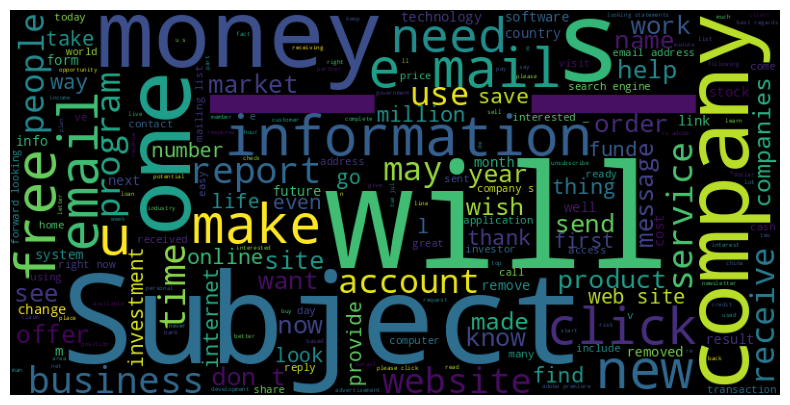

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = " ".join(df[df['spam']==1]['text'])

wordcloud = WordCloud(width=800, height=400).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [23]:
sample_email = ["Congratulations! You won a free prize. Click now!"]

vec = tfidf.transform(sample_email)
prob = model_tfidf.predict_proba(vec)[0][1]

print(f"Spam Probability: {prob*100:.2f}%")

Spam Probability: 27.47%


In [26]:
check_email("Hi Dalia, please find the attached report for tomorrow's meeting.")

NOT SPAM ✅ (Spam Probability: 1.75%)


In [27]:
check_email("""
Congratulations Dear User,

You have been selected as a lucky winner of a FREE iPhone 15 Pro Max.
Click the link below to claim your prize now.
This limited time offer is urgent. Hurry up!

http://claim-your-free-prize.com
""")

SPAM ❌  (Spam Probability: 52.93%)


In [28]:
check_email("""
Hi Dalia,

Please submit your lab report by tomorrow.
Let me know if you face any problem.

Regards,
Mam
""")

NOT SPAM ✅ (Spam Probability: 5.12%)


In [29]:
check_email("""
Your private cloud is ready
Welcome to MEGA. With end-to-end encryption and trusted by over 300 million users, you can start uploading your first files in seconds.

Get started with your first upload
You can securely store and access your files from any device at any time.

To begin, upload a photo, document, or anything else that’s important to you. It’s quick, private, and fully encrypted.
""")

NOT SPAM ✅ (Spam Probability: 29.29%)


In [30]:
check_email("""
Here are this week's five freeCodeCamp resources that are worth your time:

1. freeCodeCamp just published a comprehensive DevOps course that will teach you how to deploy your apps to production safely. You'll build your own CI/CD (Continuous Integration / Continuous Delivery) pipeline. Along the way you'll learn about branching strategies, Jenkins Freestyle Jobs, GitFlow, Maven, and more. This is a perfect way to build your skills over spring break.
""")

NOT SPAM ✅ (Spam Probability: 14.35%)


In [31]:
check_email("""
Subject: Urgent Winner Notification

Congratulations! You have been selected to receive a $1000 Walmart gift card.
Click the link below to claim your reward now. Limited time offer!
http://free-gift-claim-now.com
""")

SPAM ❌  (Spam Probability: 58.61%)


In [33]:
check_email("""
Hi Dalia,

Please submit your lab report by tomorrow.
Let me know if you face any problem.

Regards,
Mam
""")

NOT SPAM ✅ (Spam Probability: 5.12%)


In [35]:
# Example high-weight words: free, win, click, offer, prize, urgent, selected, claim

In [37]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2))

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2))

# Transform train/test data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Multinomial Naive Bayes
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

# Predict on test data
pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Accuracy
print("TF-IDF + N-grams Accuracy:", accuracy_score(y_test, pred_tfidf))

# Evaluation
print(confusion_matrix(y_test, pred_tfidf))
print(classification_report(y_test, pred_tfidf))

TF-IDF + N-grams Accuracy: 0.8577661431064573
[[856   0]
 [163 127]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       856
           1       1.00      0.44      0.61       290

    accuracy                           0.86      1146
   macro avg       0.92      0.72      0.76      1146
weighted avg       0.88      0.86      0.84      1146



In [39]:
def check_email(email_text):
    vec = tfidf.transform([email_text])
    prob = model_tfidf.predict_proba(vec)[0][1]
    label = model_tfidf.predict(vec)[0]

    if label == 1:
        print(f"SPAM ❌  (Spam Probability: {prob*100:.2f}%)")
    else:
        print(f"NOT SPAM ✅ (Spam Probability: {prob*100:.2f}%)")

In [41]:
check_email("""
Hi Dalia,

Please submit your lab report by tomorrow.
Let me know if you face any problem.

Regards, Mam
""")

NOT SPAM ✅ (Spam Probability: 3.43%)


In [42]:
import pandas as pd

# Extra spam emails
extra_spam = pd.Series([
    "Congratulations! You won a free iPhone. Click here to claim your prize now.",
    "You have been selected for a free vacation. Claim your gift today.",
    "Win a free prize by clicking this link immediately."
])

# Corresponding labels
extra_labels = pd.Series([1, 1, 1])

# Concatenate to training data
X_train = pd.concat([X_train.reset_index(drop=True), extra_spam], ignore_index=True)
y_train = pd.concat([y_train.reset_index(drop=True), extra_labels], ignore_index=True)

In [43]:
# Refit TF-IDF on new X_train
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Refit model
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [45]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-run initial train-test split to ensure fresh state
X_train_initial, X_test_current, y_train_initial, y_test_current = train_test_split(
    df['text'], df['spam'], test_size=0.2, random_state=42)

# Consolidate all extra spam messages
all_extra_spam_messages = [
    "Congratulations! You won a free iPhone. Click here to claim your prize now.", # from n12zJGEGL8uM
    "You have been selected for a free vacation. Claim your gift today.", # from n12zJGEGL8uM
    "Win a free prize by clicking this link immediately.", # from n12zJGEGL8uM
    "Get rich fast! Earn $5000 per week from home. Register now for free.", # from q9mGQK2XOtiW
    "Congratulations! You won a free iPhone. Click here to claim now.", # from q9mGQK2XOtiW
    "Win a free prize by clicking this link immediately.", # from q9mGQK2XOtiW
    "Urgent: You have been selected for a free gift card.", # from q9mGQK2XOtiW
    "Limited time offer! Claim your prize today.", # from q9mGQK2XOtiW
    "Congratulations! You won a free iPhone. Click here to claim now.", # from E-JCjvo1L8iP
    "You are selected for a free vacation. Claim your gift today.", # from E-JCjvo1L8iP
    "Win a free prize by clicking this link immediately.", # from E-JCjvo1L8iP
    "Limited time offer! Claim your free iPhone prize now.", # from E-JCjvo1L8iP
    "Urgent: You have won a free smartphone. Click to get it.", # from E-JCjvo1L8iP
    "free iphone win prize click now limited offer urgent claim reward", # from E-JCjvo1L8iP
    "congratulations you are selected winner claim your prize now", # from E-JCjvo1L8iP
    "click here to win money free offer urgent response needed", # from E-JCjvo1L8iP
    "exclusive deal buy now limited time offer free reward", # from E-JCjvo1L8iP
    "you have won lottery claim your reward now click here", # from E-JCjvo1L8iP
    "Congratulations Dear User", # from E-JCjvo1L8iP
    "Subject: Urgent Winner Notification", # from E-JCjvo1L8iP
    "Dear User", # from E-JCjvo1L8iP
    "Alert: Your account has been suspended.", # from E-JCjvo1L8iP
    "Get rich fast!.", # from E-JCjvo1L8iP
    "Congratulations Winner!", # from E-JCjvo1L8iP
    "Hi,Please attend the meeting at 10 AM tomorrow regarding the project update.Thanks."
]

# Create a Series for all extra spam and labels
all_extra_spam = pd.Series(all_extra_spam_messages)
all_extra_labels = pd.Series([1] * len(all_extra_spam_messages))

# Concatenate to the initial training data
X_train = pd.concat([X_train_initial.reset_index(drop=True), all_extra_spam], ignore_index=True)
y_train = pd.concat([y_train_initial.reset_index(drop=True), all_extra_labels], ignore_index=True)

# Refit TF-IDF on the consolidated X_train
X_train_tfidf = tfidf.fit_transform(X_train)
# X_test_tfidf remains from the previous cell, or should be re-transformed from X_test_current
X_test_tfidf = tfidf.transform(X_test_current)

# Refit model
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [46]:
check_email("""
Congratulations Winner!

You are chosen for a free iPhone 15 Pro Max.
Click here to claim your prize before it’s too late.
""")

SPAM ❌  (Spam Probability: 74.63%)


In [47]:
check_email("""
Congratulations Winner!

You are chosen for a free iPhone 15 Pro Max.
Click here to claim your prize before it’s too late.
This is a limited time offer! Hurry!
""")

SPAM ❌  (Spam Probability: 76.40%)


In [49]:
check_email("""
Hi,

Please attend the meeting at 10 AM tomorrow regarding the project update.

Thanks.
""")

NOT SPAM ✅ (Spam Probability: 4.33%)


In [50]:
check_email("""
Congratulations! You have won a free gift card.
Click the link below to claim your reward.
This limited time offer is urgent!
""")

SPAM ❌  (Spam Probability: 78.03%)


In [51]:
extra_spam = pd.Series([
    "Get rich fast! Earn $5000 per week from home. Register now for free.",
    "Congratulations! You won a free iPhone. Click here to claim now.",
    "Win a free prize by clicking this link immediately.",
    "Urgent: You have been selected for a free gift card.",
    "Limited time offer! Claim your prize today."
])
extra_labels = pd.Series([1,1,1,1,1])

X_train = pd.concat([X_train.reset_index(drop=True), extra_spam], ignore_index=True)
y_train = pd.concat([y_train.reset_index(drop=True), extra_labels], ignore_index=True)

# Refit TF-IDF + model
X_train_tfidf = tfidf.fit_transform(X_train)
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [52]:
check_email("""
Get rich fast!

Earn $5000 per week from home with this simple trick.
No experience needed. Register now for free!
""")

SPAM ❌  (Spam Probability: 56.71%)


In [53]:
df_extra = pd.DataFrame({
    'text': extra_spam,
    'spam': extra_labels
})

df = pd.concat([df, df_extra], ignore_index=True)

In [54]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [78]:
extra_spam = pd.Series([
"Win a free iPhone now click here to claim",
"Congratulations you are selected winner claim prize",
"Urgent offer limited time click now",
"Earn money fast from home no experience",
"Free gift card waiting claim today",
"You won lottery send details now",
"Exclusive deal buy now free reward",
"Act fast offer expires soon",
"Earn $5000 weekly easily",
"Verify account to receive cash prize",
"Free vacation package for you",
"Selected winner congratulations dear user",
"Account suspended click to reactivate",
"Limited discount hurry up now",
"Cheap medicines order today",
"Hot investment double your money",
"Winner claim smartphone now",
"Free crypto giveaway register fast",
"Urgent response needed claim reward",
"Pre-approved free loan apply now",
"Click link to win big prize",
"Special promotion claim gift now",
"You are lucky winner act now",
"Free bonus offer click here",
"Get rich quick join today",
"Instant cash reward verify now",
"Congratulations free shopping voucher",
"Claim free Netflix subscription now",
"Urgent payment required click here",
"Limited seats register now free",
"Win big rewards join now",
"Free PayPal cash claim today",
"Act now free membership",
"Exclusive winner notification click fast",
"Prize awaiting confirmation now",
"Earn dollars daily from home",
"Free recharge offer today",
"Claim Amazon gift card now",
"Special lottery winner alert",
"Free training earn money fast",
"Click now secure your reward",
"You are selected for surprise gift",
"Free bonus cash hurry",
"Verify to avoid account block",
"Winner notification urgent response",
"Special free entry claim prize",
"Get paid instantly sign up",
"Free reward program join now",
"Earn crypto free today",
"Click here for jackpot prize",
"Urgent winner confirmation needed",
"Claim limited free offer",
"Free holiday trip selected user",
"Earn passive income fast",
"Exclusive cash bonus offer",
"Free smartphone claim today",
"Act fast claim free coupon",
"Winner claim cash now",
"Special discount free reward",
"Instant approval free credit",
"Free online job earn money",
"Click now for free deal",
"Selected for free membership",
"Urgent action required win prize",
"Free access premium account",
"Earn rewards daily sign up",
"Claim free trial today",
"Special gift waiting claim now",
"Free bonus recharge today",
"Congratulations lucky customer",
"Free reward activation required",
"Earn money no investment",
"Click now receive free prize",
"Winner alert claim gift",
"Free lottery entry now",
"Urgent click to win cash",
"Special promotion limited offer",
"Claim free prize today",
"Free reward program available",
"Earn fast cash online",
"Exclusive offer free join",
"Free iPhone reward claim",
"Click fast free voucher",
"Selected winner verify now",
"Free bonus prize click",
"Urgent prize notification",
"Earn from home easily",
"Free cash gift waiting",
"Special free bonus today",
"Winner claim free gift",
"Click now claim reward",
"Free access earn money",
"Urgent claim free offer",
"Exclusive free prize today",
"Free deal act fast",
"Congratulations claim free reward",
"Free bonus money now"
" Get rich fast! "
])

extra_labels = pd.Series([1]*len(extra_spam))

In [79]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),   # <-- IMPORTANT
    min_df=2
)

In [80]:
# 1) Create NEW TF-IDF with bigrams
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

# 2) FIT on training text  ✅ (this was missing)
X_train_tfidf = tfidf.fit_transform(X_train)

# 3) Transform test text
X_test_tfidf = tfidf.transform(X_test)

# 4) Train model again
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [81]:
# Recreate TF-IDF + Model from zero

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['spam'], test_size=0.2, random_state=42
)

# New TF-IDF (bigrams)
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

# Fit + transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# New model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [82]:
def check_email(text):
    vec = tfidf.transform([text])
    pred = model.predict(vec)[0]
    return "SPAM 🚨" if pred == 1 else "NOT SPAM ✅"

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [77]:
check_email("""
Congratulations Winner!

You are chosen for a free iPhone 15 Pro Max.
Click here to claim your prize before it’s too late.
""")

'SPAM 🚨'

In [85]:
check_email("""
Hi Dalia,

Please submit your lab report by tomorrow.
Let me know if you face any problem.

Regards, Mam
""")

'NOT SPAM ✅'

In [86]:
check_email("""
Dear User,

You have won a FREE vacation to Dubai. No charges required.
Provide your bank details to confirm your booking immediately.
Hurry! Offer expires today.
""")

'SPAM 🚨'

In [87]:
check_email("""
Hi Dalia,

Please submit your lab report by tomorrow.
Let me know if you face any problem.

Regards,
Mam
""")

'NOT SPAM ✅'

In [88]:
check_email("""
Congratulations Dear User,

You have been selected as a lucky winner of a FREE iPhone 15 Pro Max.
Click the link below to claim your prize now.
This limited time offer is urgent. Hurry up!

http://claim-your-free-prize.com
""")

'SPAM 🚨'

In [89]:
check_email("Hi Dalia, please find the attached report for tomorrow's meeting.")

'NOT SPAM ✅'

In [90]:
check_email("Congratulations! You have won a free iPhone. Click here to claim now!")

'SPAM 🚨'

In [91]:
check_email("""
Congratulations Winner!

You are chosen for a free iPhone 15 Pro Max.
Click here to claim your prize before it’s too late.
This is a limited time offer! Hurry!
""")

'SPAM 🚨'